# Model Monitoring: PSI, CSI, and KS Drift Detection
### Detecting distribution drift between a model's development population and current production population

This notebook builds a reusable drift-monitoring framework on the same 60,000-loan dataset used in `01_credit_risk_scorecard_pipeline.ipynb`. It answers three related but distinct questions about model monitoring:

1. **Have individual input features drifted?** (Population Stability Index, or PSI, on raw
   features)
2. **Has the model's actual output — the risk score itself — drifted?** (Characteristic
   Stability Index, or CSI, on score bands — since it reflects the model's *combined* view across all inputs)
3. **Does a second, independent statistical test agree with PSI's findings?** (Kolmogorov-Smirnov
   statistic, or KS statistic — a distribution-shape test that doesn't depend on binning choices the way PSI does)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

import lightgbm as lgb

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 1. Load data and define populations

We will split an early-vintage **development population** for what a model
would have been trained on(first 24 months), and the most recent 6 months as the **current/production
population** the model is scoring today.

In [2]:
df = pd.read_csv("../data/loan_data.csv", parse_dates=["issue_d"])
df = df.sort_values("issue_d").reset_index(drop=True)

dev_start, dev_end = df["issue_d"].min(), df["issue_d"].min() + pd.DateOffset(months=24)
recent_start = df["issue_d"].max() - pd.DateOffset(months=6)

dev_pop = df[(df["issue_d"] >= dev_start) & (df["issue_d"] < dev_end)].copy()
recent_pop = df[df["issue_d"] >= recent_start].copy()

print(f"Development population: {len(dev_pop):,} loans ({dev_start.strftime('%Y-%m')} - {(dev_end - pd.DateOffset(months=1)).strftime('%Y-%m')})")
print(f"Recent population:      {len(recent_pop):,} loans ({recent_start.strftime('%Y-%m')} - {df['issue_d'].max().strftime('%Y-%m')})")


Development population: 20,048 loans (2019-01 - 2020-12)
Recent population:      5,805 loans (2024-06 - 2024-12)


### 1.a Feature engineering and cleaning

With `dev_pop` and `recent_pop` defined, we now compute `fico_mid`, cap `annual_inc` outliers, and parse `emp_length` - all fit on the **development population only** where relevant (the income cap), then applied to both populations. This ordering matters: these steps have to happen *after* the split, since fitting the outlier cap requires `dev_pop` to already exist.

In [3]:
# 1. Feature engineering: create a new column for the mid-point of the FICO score range
dev_pop["fico_mid"] = (dev_pop["fico_range_low"] + dev_pop["fico_range_high"]) / 2
recent_pop["fico_mid"] = (recent_pop["fico_range_low"] + recent_pop["fico_range_high"]) / 2

# 2. Cap the annual income at the 99th percentile to reduce the influence of outliers
income_cap = dev_pop["annual_inc"].quantile(0.99)  # fit on dev_pop ONLY


# 3. Create a function to parse the employment length column and convert it to numeric values
def parse_emp_length(val):
    if pd.isna(val):
        return np.nan
    if "< 1" in val:
        return 0
    if "10+" in val:
        return 10
    return int(val.split()[0])


# 4. Apply the income capping and employment length parsing to both development and recent populations
for frame in (dev_pop, recent_pop):
    frame["annual_inc"] = frame["annual_inc"].clip(upper=income_cap)
    frame["emp_length_years"] = frame["emp_length"].apply(parse_emp_length)

print(f"annual_inc capped at 99th percentile of development population: ${income_cap:,.0f}")


annual_inc capped at 99th percentile of development population: $173,053


## 2. Retrain the challenger model from notebook 01

To monitor the model's *score* distribution (not just raw features), we need the model itself.
This retrains the same challenger pipeline from `01_credit_risk_scorecard_pipeline.ipynb` on
the development population only — standing in for "the model as it was originally deployed" -
so we can then score the recent population with it and see how the score distribution has
moved.

In [4]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Same feature engineering logic as notebook 01 - kept identical so the model
    scored here is a fair stand-in for the deployed model."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["installment_to_income"] = X["installment"] * 12 / (X["annual_inc"] + 1)
        X["loan_to_income"] = X["loan_amnt"] / (X["annual_inc"] + 1)
        X["revol_bal_to_income"] = X["revol_bal"] / (X["annual_inc"] + 1)
        X["credit_file_depth"] = X["total_acc"] / (X["mths_since_earliest_cr_line"] / 12 + 1)
        X["high_util_flag"] = (X["revol_util"] > 80).astype(int)
        X["pay_freq_monthly_flag"] = (X["pay_frequency"] == "monthly").astype(int)
        X["cf_net_cash_flow_margin"] = 1 - X["cf_essential_spend_ratio"] - X["cf_discretionary_spend_ratio"]
        X["cf_balance_to_income_ratio"] = X["cf_avg_checking_balance"] * 12 / (X["annual_inc"] + 1)
        X["cf_distress_score"] = (
            X["cf_nsf_count_6mo"] + X["cf_overdraft_count_6mo"] + X["cf_negative_balance_days_90d"] / 10
        )
        return X


In [5]:


def build_pipeline(numeric_cols, categorical_cols, model_params):
    """Same structure as build_credit_risk_pipeline() in notebook 01 - model_params
    is passed in explicitly, so we can use the same hyperparameters as the deployed model for a fair comparison."""
    engineered_numeric = [
        "installment_to_income", "loan_to_income", "revol_bal_to_income",
        "credit_file_depth", "high_util_flag", "pay_freq_monthly_flag",
        "cf_net_cash_flow_margin", "cf_balance_to_income_ratio", "cf_distress_score",
    ]
    preprocessing = ColumnTransformer(transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_cols + engineered_numeric),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), categorical_cols),
    ])
    return Pipeline(steps=[
        ("feature_engineering", FeatureEngineer()),
        ("preprocessing", preprocessing),
        ("model", lgb.LGBMClassifier(**model_params)),
    ])


# Same model_params as notebook 01
model_params = dict(
    n_estimators=400, max_depth=5, num_leaves=31, learning_rate=0.04,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1,
)


In [6]:
TARGET = "charged_off"
drop_cols = ["loan_id", "issue_d", "fico_range_low", "fico_range_high", "emp_length",
             "first_payment_default", "charged_off", "grade"]
feature_cols = [c for c in dev_pop.columns if c not in drop_cols]

X_dev, y_dev = dev_pop[feature_cols], dev_pop[TARGET]
numeric_cols = X_dev.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_dev.select_dtypes(exclude=[np.number]).columns.tolist()

# Train on 75% of the development population, exactly mirroring notebook 01's split
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=RANDOM_STATE, stratify=y_dev
)

monitoring_model = build_pipeline(numeric_cols, categorical_cols, model_params)
monitoring_model.fit(X_train, y_train)
print("Model retrained on development population - standing in for the originally deployed model")


Model retrained on development population - standing in for the originally deployed model


### 2.a Identify which features to monitor, using permutation importance

Let's compute permutation importance on the retrained model - the same technique used in `01_credit_risk_scorecard_pipeline.ipynb` - and monitor the features the model actually relies on most.

In [7]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    monitoring_model, X_holdout, y_holdout, n_repeats=10, random_state=RANDOM_STATE,
    scoring="roc_auc", n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_holdout.columns,
    "importance_mean": perm_result.importances_mean,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

importance_df.head(15)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

,feature,importance_mean
0,fico_mid,0.140535
1,cf_avg_checking_balance,0.009565
2,cf_essential_spend_ratio,0.009305
3,dti,0.008721
4,cf_nsf_count_6mo,0.008385
5,int_rate,0.006018
6,pay_frequency,0.004346
7,cf_discretionary_spend_ratio,0.003847
8,cf_overdraft_count_6mo,0.003168
9,cf_existing_loan_payment_ratio,0.003167


## 3. Score both populations and compare score distributions

Now we score the development holdout and the recent population, then
compare the resulting **predicted probability distributions** directly.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


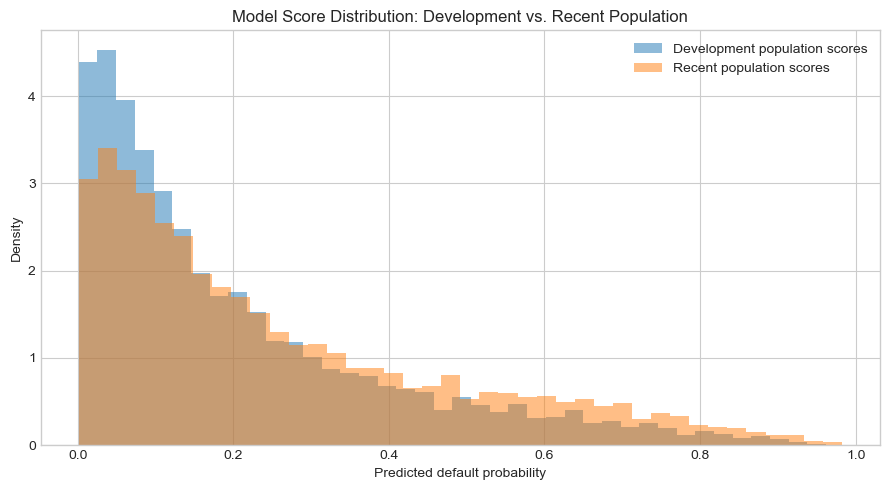

Development population mean score: 0.2068
Recent population mean score:      0.2578


In [8]:
dev_scores = monitoring_model.predict_proba(X_holdout)[:, 1]
recent_scores = monitoring_model.predict_proba(recent_pop[feature_cols])[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(dev_scores, bins=40, alpha=0.5, label="Development population scores", density=True)
ax.hist(recent_scores, bins=40, alpha=0.5, label="Recent population scores", density=True)
ax.set_xlabel("Predicted default probability")
ax.set_ylabel("Density")
ax.set_title("Model Score Distribution: Development vs. Recent Population")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/score_distribution_shift.png", dpi=120)
plt.show()

print(f"Development population mean score: {dev_scores.mean():.4f}")
print(f"Recent population mean score:      {recent_scores.mean():.4f}")

## 4. Characteristic Stability Index (CSI) on score bands

CSI applies the same PSI math, but to the model's **score deciles** rather than a raw feature.

In [9]:
def calculate_psi(dev_values, recent_values, bins=10):
    """Reusable PSI/CSI calculation - same function works on raw features (PSI) or
    model scores (CSI), since the math is identical; only the input differs."""
    dev_values = pd.Series(dev_values).dropna()
    recent_values = pd.Series(recent_values).dropna()

    breakpoints = np.percentile(dev_values, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    dev_counts = pd.cut(dev_values, bins=breakpoints, duplicates="drop").value_counts(sort=False)
    recent_counts = pd.cut(recent_values, bins=breakpoints, duplicates="drop").value_counts(sort=False)

    dev_pct = (dev_counts / dev_counts.sum()).replace(0, 0.0001)
    recent_pct = (recent_counts / recent_counts.sum()).replace(0, 0.0001)

    psi = np.sum((recent_pct - dev_pct) * np.log(recent_pct / dev_pct))
    return psi


def psi_status(psi_value):
    if psi_value < 0.10:
        return "Stable"
    elif psi_value < 0.25:
        return "Moderate shift"
    else:
        return "Significant shift"


csi_value = calculate_psi(dev_scores, recent_scores)
print(f"CSI (model score bands): {csi_value:.4f} — {psi_status(csi_value)}")


def calculate_psi_categorical(dev_values, recent_values):
    """PSI for categorical variables - same underlying formula as numeric PSI,
    but bins are the categories themselves rather than percentile-based ranges.
    Categories present in only one population are given a small floor probability
    (0.0001) so the log-ratio stays defined rather than raising a divide-by-zero."""
    dev_values = pd.Series(dev_values).dropna()
    recent_values = pd.Series(recent_values).dropna()

    dev_pct = dev_values.value_counts(normalize=True)
    recent_pct = recent_values.value_counts(normalize=True)

    all_categories = sorted(set(dev_pct.index) | set(recent_pct.index))
    dev_pct = dev_pct.reindex(all_categories, fill_value=0.0001)
    recent_pct = recent_pct.reindex(all_categories, fill_value=0.0001)

    psi = np.sum((recent_pct - dev_pct) * np.log(recent_pct / dev_pct))
    return psi

CSI (model score bands): 0.0604 — Stable


## 5. PSI across key input features - numeric and categorical

Alongside CSI on the model's output, we check PSI on a broader set of individual input features - both **numeric** and **categorical**. This tells us *which* underlying features are driving any score-level shift we observe.


In [10]:
# Monitor the top 15 features by permutation importance.
# Note: engineered features (e.g., installment_to_income) exist only in the pipeline's
# internal transformed space, not as raw columns so we can only control and monitor them.
candidate_features = [f for f in importance_df["feature"] if f in dev_pop.columns]
top_features = importance_df[importance_df["feature"].isin(candidate_features)].head(15)["feature"].tolist()

numeric_monitor_vars = [f for f in top_features if f in dev_pop.select_dtypes(include=[np.number]).columns]
categorical_monitor_vars = [f for f in top_features if f in dev_pop.select_dtypes(exclude=[np.number]).columns]

print(f"Monitoring {len(numeric_monitor_vars)} numeric and {len(categorical_monitor_vars)} categorical features,")
print(f"selected from the top 15 by permutation importance (of those available as raw columns).")
print(f"\nNumeric: {numeric_monitor_vars}")
print(f"Categorical: {categorical_monitor_vars}")

psi_results = []
for var in numeric_monitor_vars:
    psi_value = calculate_psi(dev_pop[var], recent_pop[var])
    psi_results.append({"variable": var, "type": "numeric", "psi": psi_value, "status": psi_status(psi_value)})

for var in categorical_monitor_vars:
    psi_value = calculate_psi_categorical(dev_pop[var], recent_pop[var])
    psi_results.append({"variable": var, "type": "categorical", "psi": psi_value, "status": psi_status(psi_value)})

# Add CSI (model score) as its own row for direct comparison
psi_results.append({"variable": "model_score (CSI)", "type": "model output", "psi": csi_value, "status": psi_status(csi_value)})

psi_df = pd.DataFrame(psi_results).sort_values("psi", ascending=False).reset_index(drop=True)
psi_df


Monitoring 14 numeric and 1 categorical features,
selected from the top 15 by permutation importance (of those available as raw columns).

Numeric: ['fico_mid', 'cf_avg_checking_balance', 'cf_essential_spend_ratio', 'dti', 'cf_nsf_count_6mo', 'int_rate', 'cf_discretionary_spend_ratio', 'cf_overdraft_count_6mo', 'cf_existing_loan_payment_ratio', 'cf_savings_rate', 'inq_last_6mths', 'cf_monthly_income_consistency', 'pub_rec', 'cf_avg_daily_balance_volatility']
Categorical: ['pay_frequency']


,variable,type,psi,status
0,fico_mid,numeric,8.625139e-02,Stable
1,int_rate,numeric,6.735052e-02,Stable
2,model_score (CSI),model output,6.039802e-02,Stable
3,cf_monthly_income_consistency,numeric,4.117580e-03,Stable
4,cf_essential_spend_ratio,numeric,3.403298e-03,Stable
5,cf_avg_daily_balance_volatility,numeric,2.424276e-03,Stable
6,cf_discretionary_spend_ratio,numeric,2.262002e-03,Stable
7,cf_avg_checking_balance,numeric,2.243168e-03,Stable
8,cf_savings_rate,numeric,1.865449e-03,Stable
9,dti,numeric,1.566229e-03,Stable


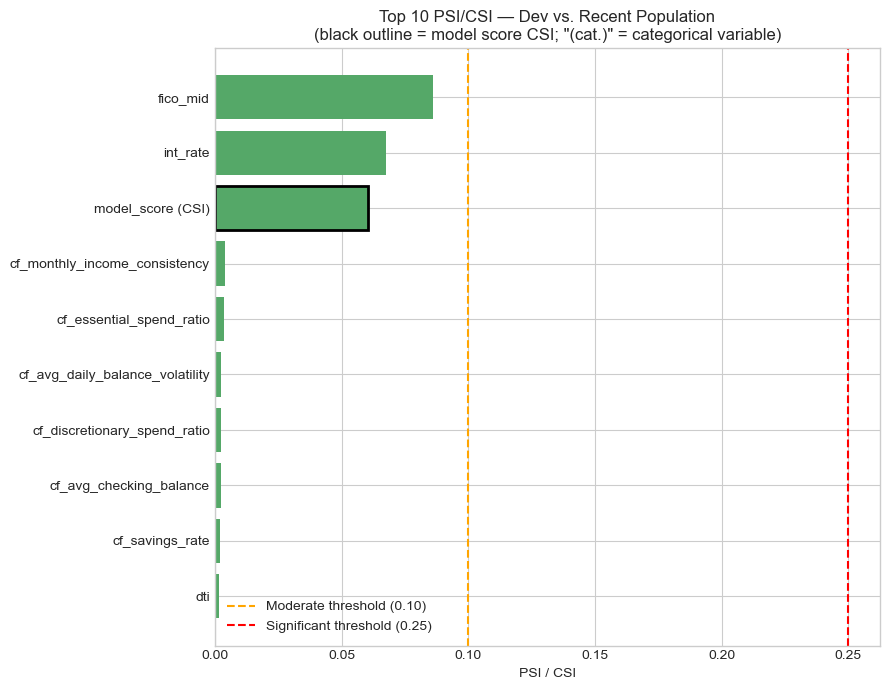

In [11]:
# Show the top 10 most-drifted variables for chart readability.
top_n = 10
plot_df = psi_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#C44E52" if s == "Significant shift" else "#DD8452" if s == "Moderate shift" else "#55A868"
          for s in plot_df["status"]]
edge_colors = ["black" if v == "model_score (CSI)" else "none" for v in plot_df["variable"]]
labels = [f"{v} (cat.)" if t == "categorical" else v for v, t in zip(plot_df["variable"], plot_df["type"])]
ax.barh(labels, plot_df["psi"], color=colors, edgecolor=edge_colors, linewidth=2)
ax.axvline(0.10, color="orange", linestyle="--", label="Moderate threshold (0.10)")
ax.axvline(0.25, color="red", linestyle="--", label="Significant threshold (0.25)")
ax.invert_yaxis()
ax.set_xlabel("PSI / CSI")
ax.set_title(f"Top {top_n} PSI/CSI — Dev vs. Recent Population\n(black outline = model score CSI; \"(cat.)\" = categorical variable)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/psi_summary.png", dpi=120)
plt.show()


## 6. Cross-checking with the Kolmogorov-Smirnov (KS) test

The **two-sample KS test** measures the maximum distance between
two cumulative distributions directly, without any binning.

We run KS on the same set of variables + the model score so every PSI/CSI finding above.

In [12]:
# KS test applies to numeric variables only - it's a continuous-distribution test
# and doesn't have a meaningful categorical equivalent. For categoricals, PSI (and
# a chi-square test, not shown here) is the standard approach instead.
ks_results = []
for var in numeric_monitor_vars:
    stat, p_value = ks_2samp(dev_pop[var].dropna(), recent_pop[var].dropna())
    ks_results.append({"variable": var, "ks_statistic": stat, "p_value": p_value})

ks_stat_score, ks_p_score = ks_2samp(dev_scores, recent_scores)
ks_results.append({"variable": "model_score (CSI)", "ks_statistic": ks_stat_score, "p_value": ks_p_score})

ks_df = pd.DataFrame(ks_results).sort_values("ks_statistic", ascending=False).reset_index(drop=True)

# Merge PSI/CSI and KS side by side for direct comparison - categorical variables
# won't have a KS row and will show NaN for ks_statistic/p_value, which is expected
comparison_df = psi_df.merge(ks_df, on="variable", how="left")
comparison_df["ks_significant"] = comparison_df["p_value"] < 0.05
comparison_df


,variable,type,psi,status,ks_statistic,p_value,ks_significant
0,fico_mid,numeric,8.625139e-02,Stable,0.117536,1.207709e-54,True
1,int_rate,numeric,6.735052e-02,Stable,0.111616,2.623823e-49,True
2,model_score (CSI),model output,6.039802e-02,Stable,0.102430,5.115379e-25,True
3,cf_monthly_income_consistency,numeric,4.117580e-03,Stable,0.016656,1.625919e-01,False
4,cf_essential_spend_ratio,numeric,3.403298e-03,Stable,0.017335,1.320716e-01,False
5,cf_avg_daily_balance_volatility,numeric,2.424276e-03,Stable,0.021514,3.946560e-02,True
6,cf_discretionary_spend_ratio,numeric,2.262002e-03,Stable,0.012572,4.714339e-01,False
7,cf_avg_checking_balance,numeric,2.243168e-03,Stable,0.014153,3.248914e-01,False
8,cf_savings_rate,numeric,1.865449e-03,Stable,0.010138,7.398179e-01,False
9,dti,numeric,1.566229e-03,Stable,0.007942,9.367624e-01,False


**Based on above table:** `p_value < 0.05` means the KS test is statistically confident the two
populations' distributions genuinely differ. Comparing this
column against the PSI/CSI `status` column shows whether the two independent methods agree.

In [13]:
agreement = ((comparison_df["status"] != "Stable") == comparison_df["ks_significant"]).mean()
print(f"PSI/CSI and KS test agree on drift status for {agreement:.0%} of monitored variables")

flagged = comparison_df[(comparison_df["status"] != "Stable") & (comparison_df["ks_significant"])]
print(f"\nVariables flagged by BOTH methods (highest-confidence drift signals):")
print(flagged[["variable", "psi", "ks_statistic", "p_value"]].to_string(index=False))

PSI/CSI and KS test agree on drift status for 75% of monitored variables

Variables flagged by BOTH methods (highest-confidence drift signals):
Empty DataFrame
Columns: [variable, psi, ks_statistic, p_value]
Index: []


## 7. Rolling monthly PSI — the early warning view

Same rolling monitoring view as before, tracking the top-drifted raw feature on a monthly
cadence against the fixed development population.

In [14]:
# Monitor rolling PSI for the top N variables by PSI, PLUS the model score CSI 
# - so we can see whether these drift together or separately
top_n_rolling = 2
top_vars_for_rolling = psi_df[psi_df["type"] == "numeric"].head(top_n_rolling)["variable"].tolist()

# The rolling view needs month-by-month slices of the FULL dataset, not just
# dev_pop/recent_pop - so engineered columns are computed here as needed.
df_rolling = df.copy()
df_rolling["fico_mid"] = (df_rolling["fico_range_low"] + df_rolling["fico_range_high"]) / 2
df_rolling["emp_length_years"] = df_rolling["emp_length"].apply(parse_emp_length)
df_rolling["annual_inc"] = df_rolling["annual_inc"].clip(upper=income_cap)

vintage_months = sorted(df_rolling["issue_d"].unique())[12:]

In [15]:
rolling_results = {var: [] for var in top_vars_for_rolling}

for month in vintage_months:
    month_pop = df_rolling[df_rolling["issue_d"] == month]
    if len(month_pop) < 30:
        continue
    for var in top_vars_for_rolling:
        psi_value = calculate_psi(dev_pop[var], month_pop[var])
        rolling_results[var].append({"month": month, "psi": psi_value})

rolling_dfs = {var: pd.DataFrame(vals) for var, vals in rolling_results.items()}

In [16]:
rolling_csi = []
for month in vintage_months:
    month_pop = df_rolling[df_rolling["issue_d"] == month]
    if len(month_pop) < 30:
        continue
    month_scores = monitoring_model.predict_proba(month_pop[feature_cols])[:, 1]
    csi_month = calculate_psi(dev_scores, month_scores)
    rolling_csi.append({"month": month, "psi": csi_month})

rolling_csi_df = pd.DataFrame(rolling_csi)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

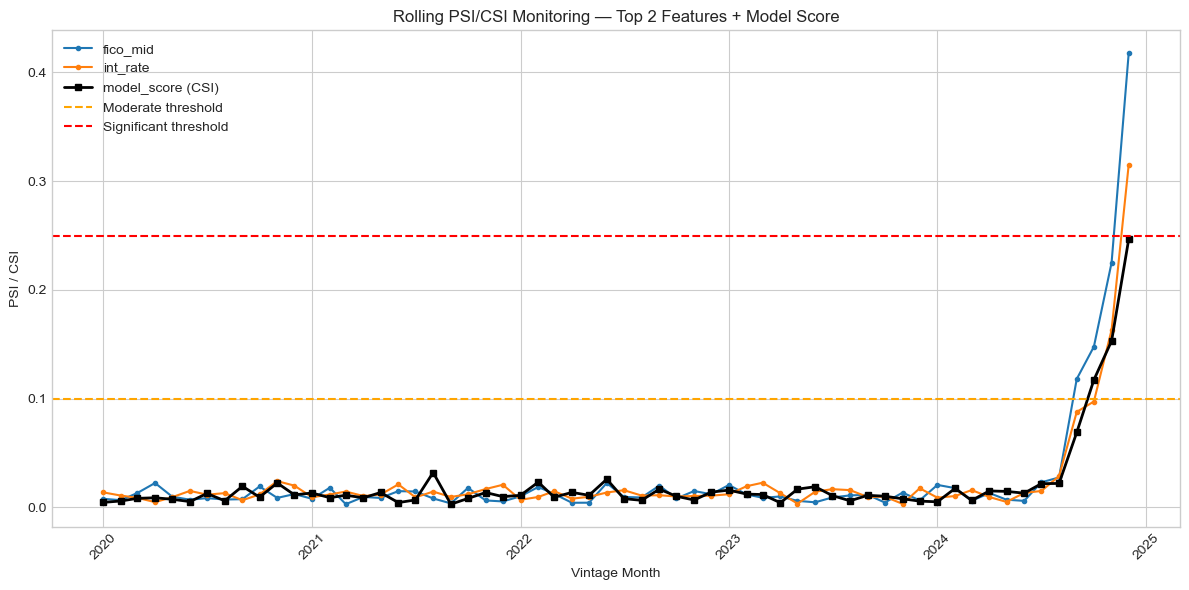

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

for var in top_vars_for_rolling:
    ax.plot(rolling_dfs[var]["month"], rolling_dfs[var]["psi"], marker="o", markersize=3, label=var)

ax.plot(rolling_csi_df["month"], rolling_csi_df["psi"], marker="s", markersize=4,
        color="black", linewidth=2, label="model_score (CSI)")

ax.axhline(0.10, color="orange", linestyle="--", label="Moderate threshold")
ax.axhline(0.25, color="red", linestyle="--", label="Significant threshold")
ax.set_xlabel("Vintage Month")
ax.set_ylabel("PSI / CSI")
ax.set_title(f"Rolling PSI/CSI Monitoring \u2014 Top {top_n_rolling} Features + Model Score")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/rolling_psi.png", dpi=120)
plt.show()

## 8. Business summary

In [24]:
# Just print out the numbers for the top variables so I can see them at a glance
print("MODEL MONITORING SUMMARY")
print("=" * 70)

print("\n6-month snapshot PSI:")
for var in top_vars_for_rolling:
    val = psi_df.loc[psi_df["variable"] == var, "psi"].values[0]
    print(f"  {var}: {val:.3f}")

print(f"  model score CSI: {csi_value:.3f} ({psi_status(csi_value)})")

final_month = pd.Timestamp(vintage_months[-1]).strftime("%Y-%m")
print(f"\nMost recent month ({final_month}) rolling PSI:")
for var in top_vars_for_rolling:
    val = rolling_dfs[var]["psi"].iloc[-1]
    print(f"  {var}: {val:.3f}")
print(f"  model score CSI: {rolling_csi_df['psi'].iloc[-1]:.3f}")

n_ks_agree = len(flagged)
print(f"\n{n_ks_agree} of {len(numeric_monitor_vars) + 1} variables confirmed by both PSI/CSI and KS")

print("\nTakeaway: the snapshot alone looks stable, but the rolling trend shows " \
    " \n fico_mid and int_rate drifting fast in the most recent months, and needs to be monitored closely.")


MODEL MONITORING SUMMARY

6-month snapshot PSI:
  fico_mid: 0.086
  int_rate: 0.067
  model score CSI: 0.060 (Stable)

Most recent month (2024-12) rolling PSI:
  fico_mid: 0.418
  int_rate: 0.315
  model score CSI: 0.247

0 of 15 variables confirmed by both PSI/CSI and KS

Takeaway: the snapshot alone looks stable, but the rolling trend shows  
 fico_mid and int_rate drifting fast in the most recent months, and needs to be monitored closely.
